In [1]:
import utils
import numpy as np
import pandas as pd
import os
import re
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [2]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Preparation
pilot_analysis = False
split_dataset = False
plot_range = [0, 6]

if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    unique_subject_ids = [802,803,804,805,806,808,809,811,813,814,815]
    unique_sessions = [1]
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
    unique_subject_ids = [5, 10, 13, 14, 15, 16, 20, 22, 23, 25, 27, 28, 29, 30, 32, 37]#[5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37]
    unique_sessions = [1]
    if unique_sessions != [1]:
        split_dataset = True

combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, pilot_analysis, remove_reversals=True)
#combined_results_dataframe.to_csv(os.path.join(output_dir, 'combined_results_kenneth.csv'), index=False, sep=';')

['/Volumes/project/3025011.02/raw/sub-005/ses-mri01/beh/behavioural_output_sub-005_session-01_dummy_2025-03-07_17-11-43.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri01/beh/behavioural_output_sub-010_session-01_dummy_2025-03-11_11-18-41.csv', '/Volumes/project/3025011.02/raw/sub-013/ses-mri01/beh/behavioural_output_sub-013_session-01_dummy_2025-03-20_13-19-45.csv', '/Volumes/project/3025011.02/raw/sub-014/ses-mri01/beh/behavioural_output_sub-014_session-01_dummy_2025-03-21_10-45-03.csv', '/Volumes/project/3025011.02/raw/sub-015/ses-mri01/beh/behavioural_output_sub-015_session-01_dummy_2025-05-21_17-11-48.csv', '/Volumes/project/3025011.02/raw/sub-016/ses-mri01/beh/behavioural_output_sub-016_session-01_dummy_2025-05-16_09-53-49.csv', '/Volumes/project/3025011.02/raw/sub-020/ses-mri01/beh/behavioural_output_sub-020_session-01_dummy_2025-05-22_09-46-37.csv', '/Volumes/project/3025011.02/raw/sub-022/ses-mri01/beh/behavioural_output_sub-022_session-01_dummy_2025-05-22_14-16-23.csv',

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [4]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Split the dataframe
So that combined_results_dataframe has the results you want to analyse but the combined_results_dataframe_all_sessions includes the 1st session as well

In [5]:
if split_dataset:
    combined_results_dataframe_all_sessions = combined_results_dataframe
    combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['session'] != 'session-01']

# Objectively correct answer binned after every reversal
Sorted for valence

In [6]:
# Create a dataframe with objectively correct responses up to 12 trials after reversal
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'valence', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'valence'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_reversals_dataframe)

     subject_id  trial  stimuli_type  probability_condition  reversal valence
0       sub-005     11             1                     80     False   angry
1       sub-005     13             1                     80     False   angry
2       sub-005     14             1                     80     False   angry
3       sub-005     16             1                     80     False   angry
4       sub-005     18             1                     80     False   angry
...         ...    ...           ...                    ...       ...     ...
9581    sub-037    656             2                     20      True   happy
9582    sub-037    660             2                     20     False   happy
9583    sub-037    661             2                     20     False   happy
9584    sub-037    663             2                     20     False   happy
9585    sub-037    667             2                     20     False   happy

[9586 rows x 6 columns]
0   subject_id stimuli_type valence  0 

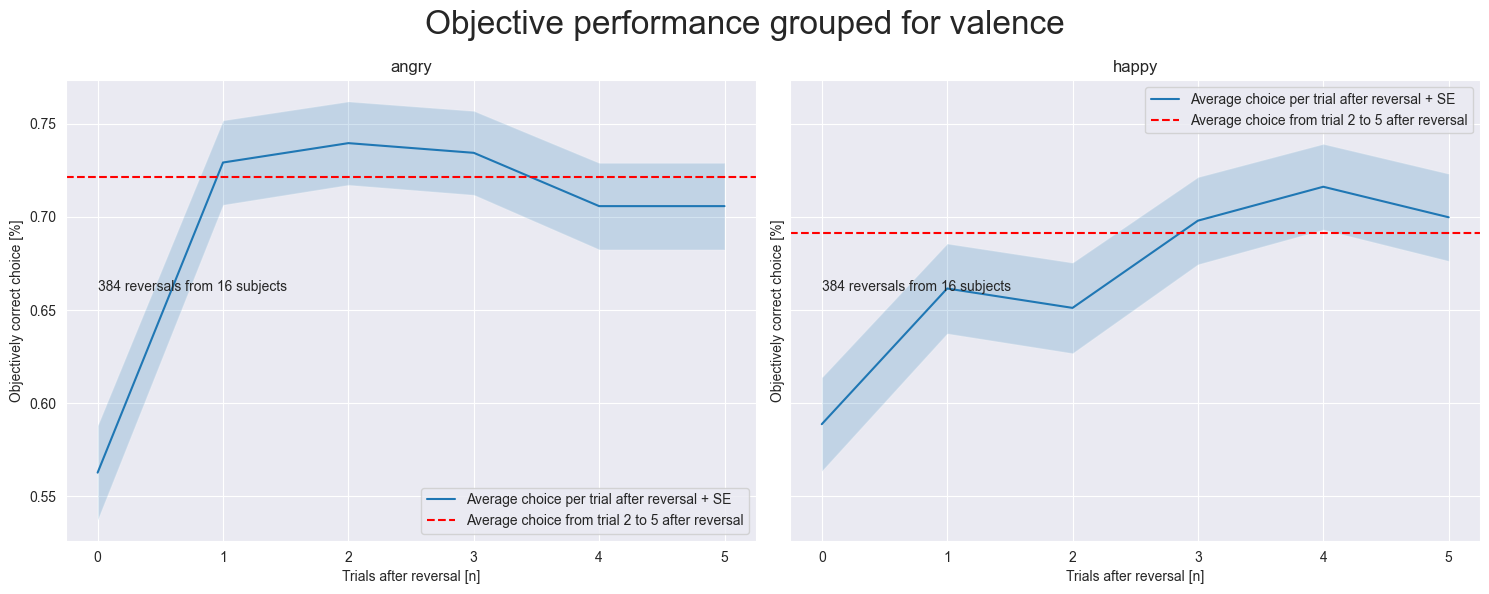

In [7]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['valence'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['valence']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['valence']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence', fontsize=24, y=0.982)

congruency_list = df['valence'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 after reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('Trials after reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.66, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence.pdf'))
plt.show()

# Now the same but split for congruency

In [8]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             'congruency', plot_range, mapping)
print(all_reversals_dataframe)

     subject_id  trial  stimuli_type  probability_condition  reversal  \
0       sub-005     11             1                     80     False   
1       sub-005     13             1                     80     False   
2       sub-005     14             1                     80     False   
3       sub-005     16             1                     80     False   
4       sub-005     18             1                     80     False   
...         ...    ...           ...                    ...       ...   
9581    sub-037    656             2                     20      True   
9582    sub-037    660             2                     20     False   
9583    sub-037    661             2                     20     False   
9584    sub-037    663             2                     20     False   
9585    sub-037    667             2                     20     False   

     congruency  
0     congruent  
1     congruent  
2     congruent  
3     congruent  
4     congruent  
...         ...

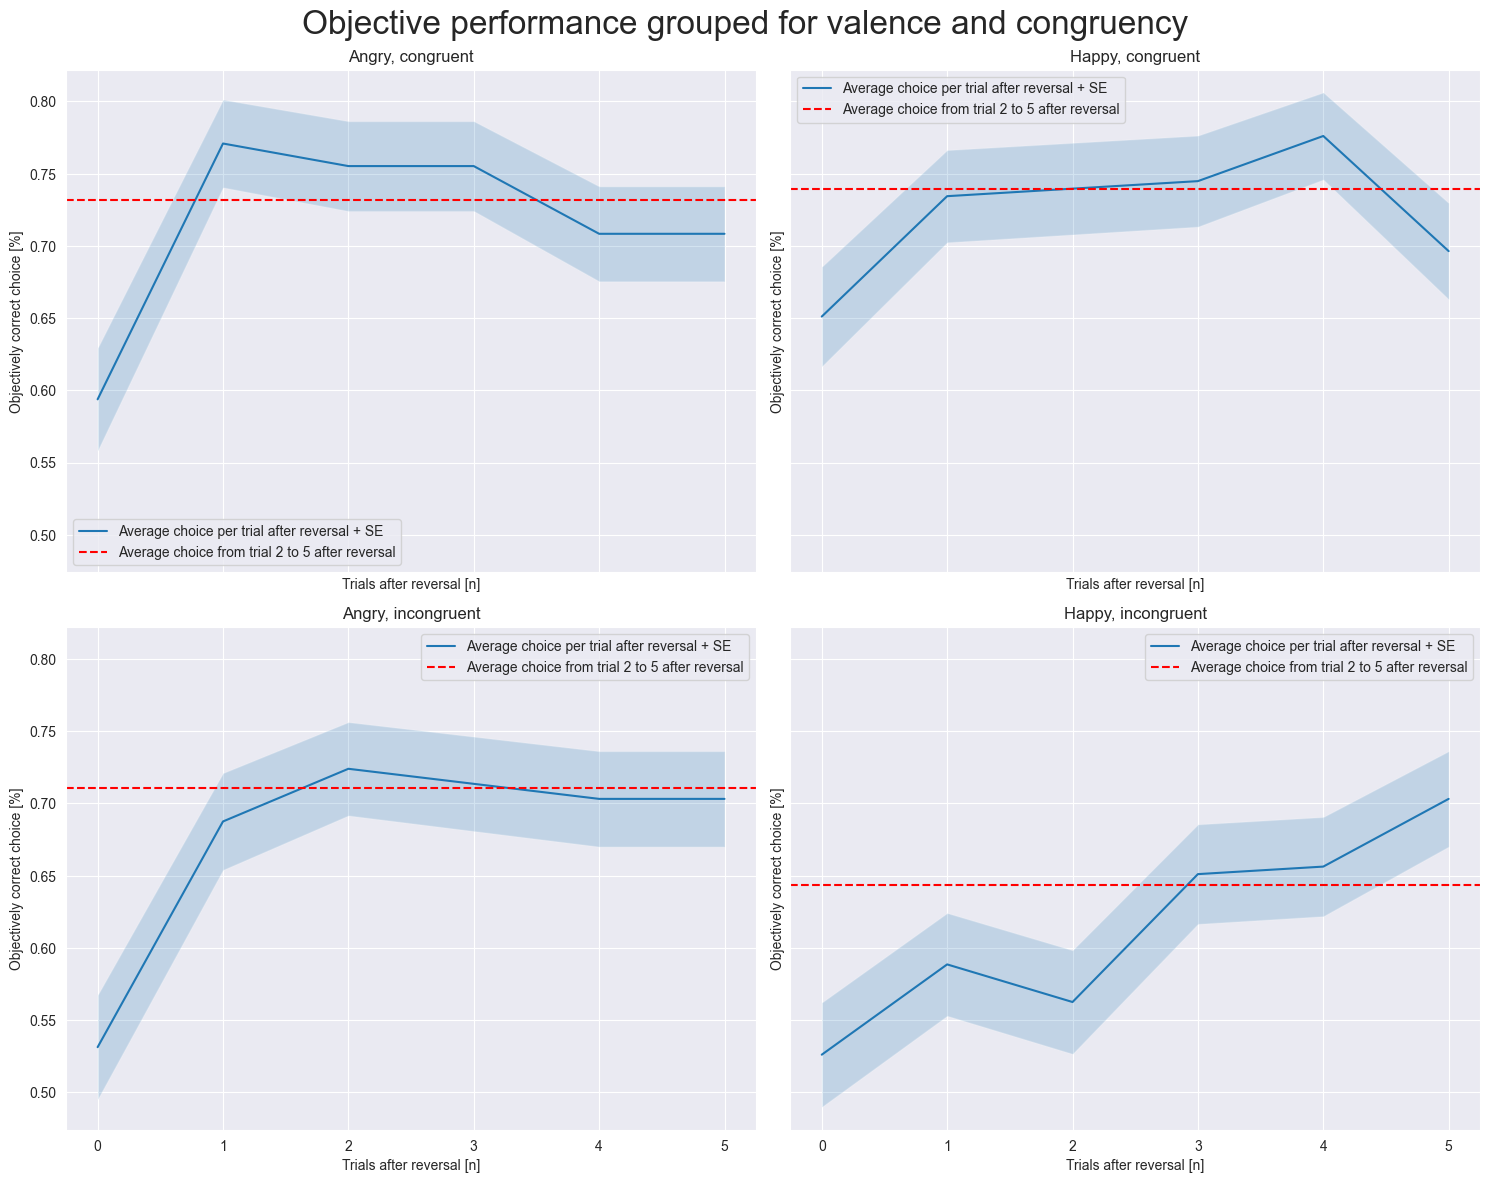

In [9]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'stimuli_type']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'stimuli_type']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
stimuli_list = df['stimuli_type'].unique()
stimuli_types_list = ['Angry', 'Angry', 'Happy', 'Happy']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 after reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{stimuli_types_list[congruency_type[1]]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence_and_congruency.pdf'))
plt.show()

# Plotting just the responses
As a check to see if giving the two types of responses was equally as difficult

In [10]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'response', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'response'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_reversals_dataframe)

     subject_id  trial  stimuli_type  probability_condition  reversal response
0       sub-005     11             1                     80     False       up
1       sub-005     13             1                     80     False       up
2       sub-005     14             1                     80     False       up
3       sub-005     16             1                     80     False       up
4       sub-005     18             1                     80     False       up
...         ...    ...           ...                    ...       ...      ...
9581    sub-037    656             2                     20      True     down
9582    sub-037    660             2                     20     False     down
9583    sub-037    661             2                     20     False     down
9584    sub-037    663             2                     20     False       up
9585    sub-037    667             2                     20     False     down

[9586 rows x 6 columns]
0   subject_id stimuli_type

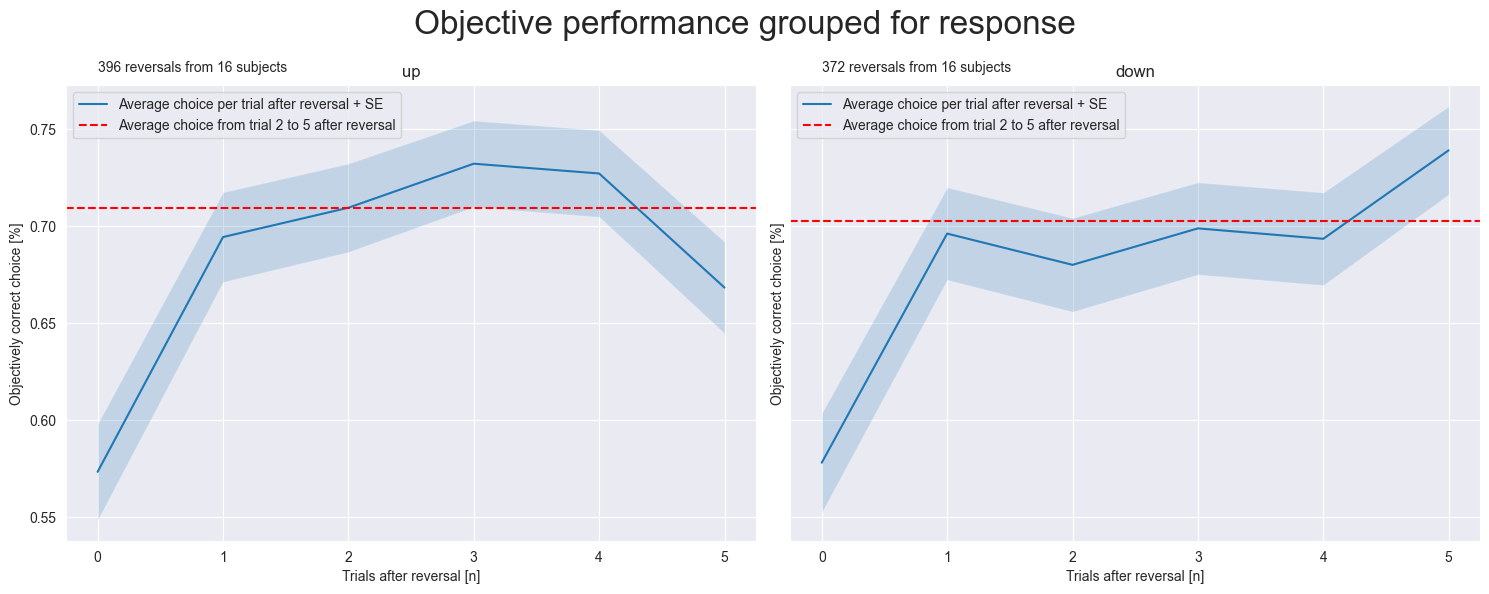

In [11]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['response'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response', fontsize=24, y=0.982)

congruency_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 after reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('Trials after reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.78, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response.pdf'))
plt.show()

# Now plot subplots for the responses and congruency
To see whether giving one type of response interacted with congruency, also as a check

In [12]:
# Create new plots with different intervals that also contain the 50% trials
group_name_1 = 'congruency'
group_name_2 = 'response'
initial_columns = {0: 'stimuli_type', 1: 'subject_id', 2: group_name_2, 3: group_name_1}
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+4: v for k, v in enumerate(plot_range)})

dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name_1, plot_range, mapping, group_name_2)
print(dataframe)

     subject_id  trial  stimuli_type  probability_condition  reversal  \
0       sub-005     11             1                     80     False   
1       sub-005     13             1                     80     False   
2       sub-005     14             1                     80     False   
3       sub-005     16             1                     80     False   
4       sub-005     18             1                     80     False   
...         ...    ...           ...                    ...       ...   
9581    sub-037    656             2                     20      True   
9582    sub-037    660             2                     20     False   
9583    sub-037    661             2                     20     False   
9584    sub-037    663             2                     20     False   
9585    sub-037    667             2                     20     False   

     congruency response  
0     congruent       up  
1     congruent       up  
2     congruent       up  
3     congruent

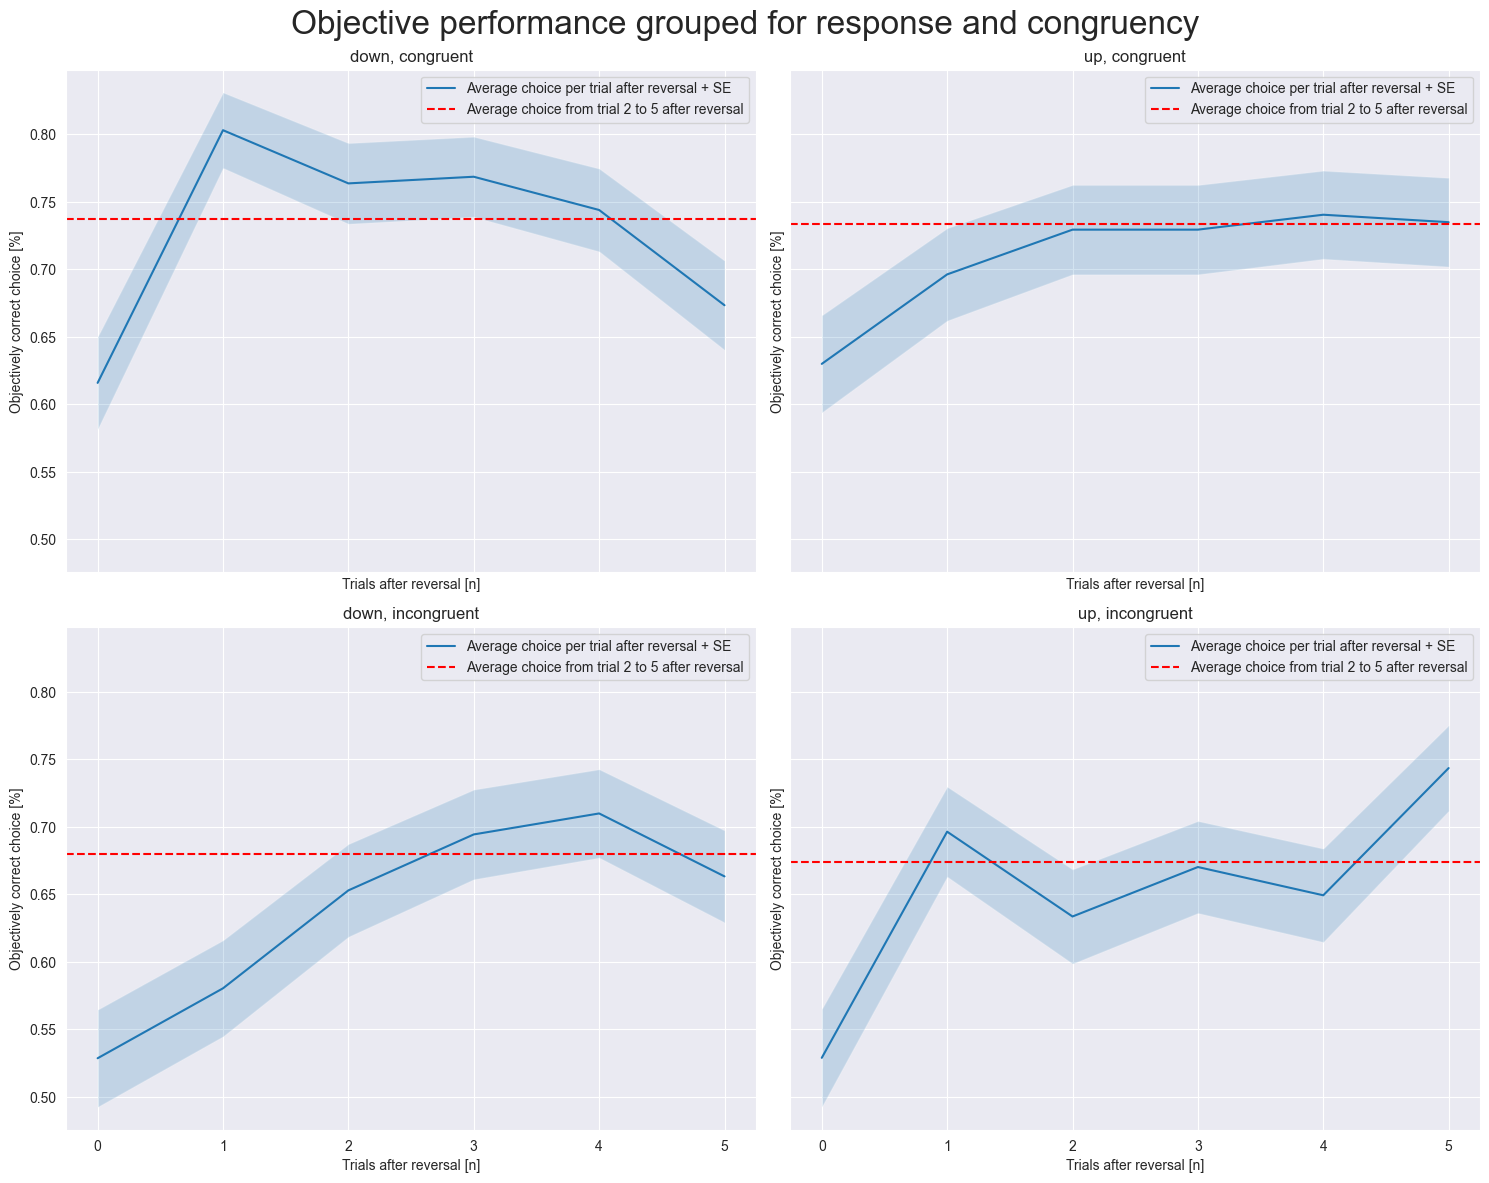

In [13]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 after reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
        axs[i].set_xlabel('Trials after reversal [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].legend()
        axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response_and_congruency.pdf'))
plt.show()

# Objectively correct answers binned around a reversal
Starting 12 trials before the reversal and ending 4 after.

In [14]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_reversal_block = pd.DataFrame()
adjusted_plot_range = [plot_range[0] - plot_range[1] + 1, plot_range[1]]

all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, adjusted_plot_range, mapping)
print(all_reversals_dataframe)

     subject_id  trial  stimuli_type  probability_condition  reversal response
0       sub-005     11             1                     80     False       up
1       sub-005     13             1                     80     False       up
2       sub-005     14             1                     80     False       up
3       sub-005     16             1                     80     False       up
4       sub-005     18             1                     80     False       up
...         ...    ...           ...                    ...       ...      ...
9581    sub-037    656             2                     20      True     down
9582    sub-037    660             2                     20     False     down
9583    sub-037    661             2                     20     False     down
9584    sub-037    663             2                     20     False       up
9585    sub-037    667             2                     20     False     down

[9586 rows x 6 columns]
0   subject_id stimuli_type

# Subplots for incongruent and congruent reversals

In [15]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_reversals_dataframe)

     subject_id  trial  stimuli_type  probability_condition  reversal  \
0       sub-005     11             1                     80     False   
1       sub-005     13             1                     80     False   
2       sub-005     14             1                     80     False   
3       sub-005     16             1                     80     False   
4       sub-005     18             1                     80     False   
...         ...    ...           ...                    ...       ...   
9581    sub-037    656             2                     20      True   
9582    sub-037    660             2                     20     False   
9583    sub-037    661             2                     20     False   
9584    sub-037    663             2                     20     False   
9585    sub-037    667             2                     20     False   

     congruency     session  
0     congruent  session-01  
1     congruent  session-01  
2     congruent  session-01  
3  

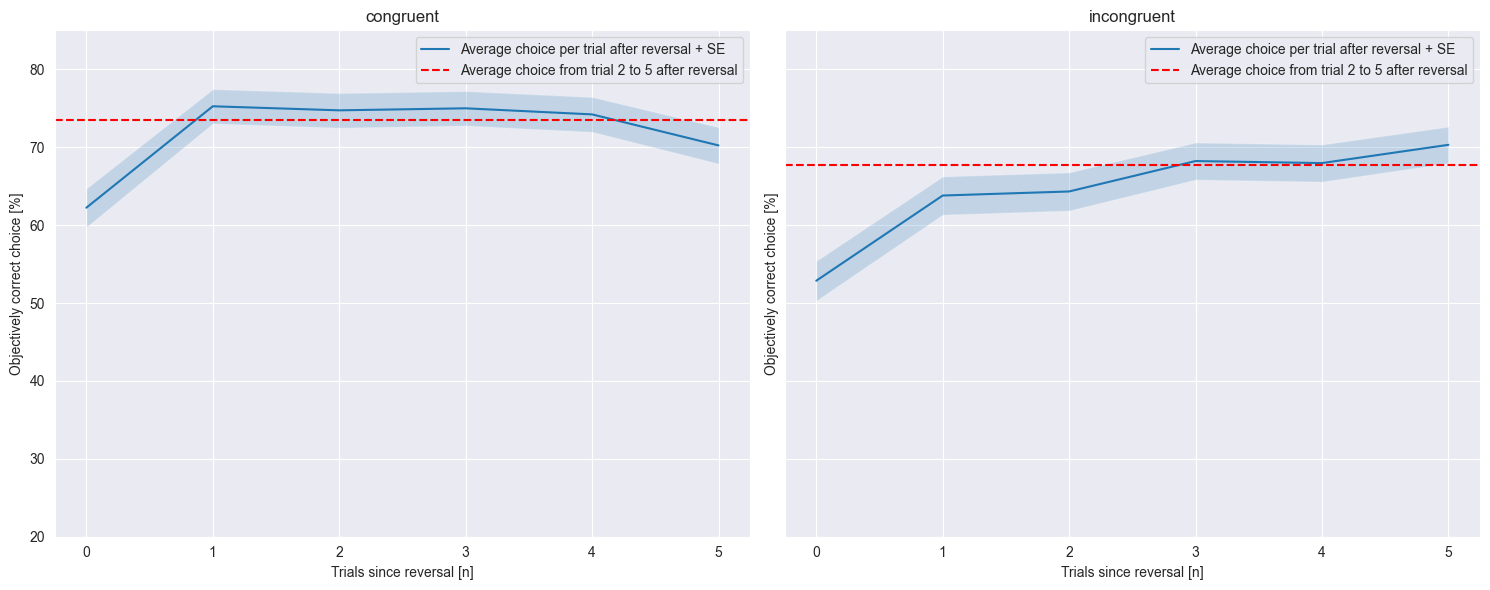

In [16]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_reversals_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 after reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials since reversal [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        #axs[i].text(-0.2, 72.5, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency.pdf'))
plt.show()

## Comparing congruency direction

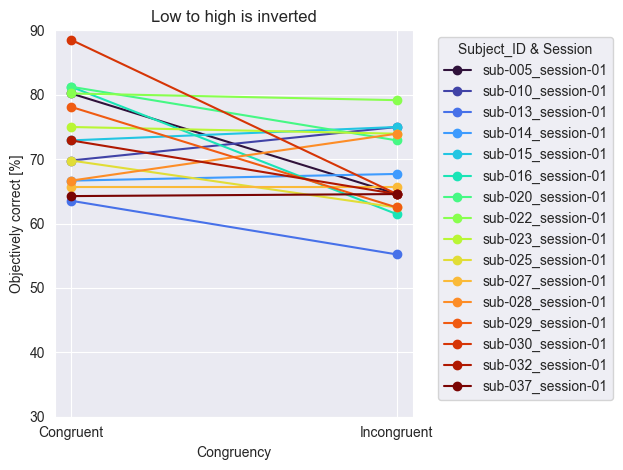

In [17]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('congruency')
df['subject_id_session'] = df['subject_id'] + '_' + df['session']

unique_subjects = df['subject_id_session'].unique()
subject_counts = len(unique_subjects)

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency','subject_id_session']).mean()
means_overall = means*100
means_overall = means_overall.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1)

df = average_choice_after_reversal_total.reset_index()

# Create a mapping for congruency values to x-axis positions:
# 1 for 'congruent' and 2 for 'incongruent'
x_mapping = {'congruent': 1, 'incongruent': 2}
df['x'] = df['congruency'].map(x_mapping)

colour = iter(cm.turbo(np.linspace(0, 1, len(unique_subject_ids))))
prev_subject = None

# Loop through each subject and plot their corresponding data points
for subject in df['subject_id_session'].unique():
    subject_data = df[df['subject_id_session'] == subject].sort_values(by='x')
    subject_data['value'] = subject_data.iloc[:,2]
    value_congruent = subject_data.loc[subject_data['congruency'] == 'congruent', 'value'].iloc[0]
    value_incongruent = subject_data.loc[subject_data['congruency'] == 'incongruent', 'value'].iloc[0]

    # If the subject changes, increment the counter
    current_subject = subject.split('_')[0]
    if current_subject != prev_subject:
        line_colour = next(colour)
        prev_subject = current_subject

    # Choose colour based on comparison: green if incongruent is lower, red if higher
    if value_incongruent < value_congruent:
        line_color = 'green'
    elif value_incongruent > value_congruent:
        line_color = 'red'
    else:
        line_color = 'blue'  # Fallback colour if both values are equal

    plt.plot(subject_data['x'], subject_data.iloc[:, 2], marker='o', label=subject, color=line_colour)

# Set x-axis ticks and labels
plt.xticks([1, 2], ['Congruent', 'Incongruent'])
plt.xlabel('Congruency')
plt.ylabel('Objectively correct [%]')  # Replace 'Value' with your actual y-axis label if needed
plt.title('Low to high is inverted')
plt.ylim(30, 90)

# Optional: display a legend if the number of subjects is not too high
plt.legend(title='Subject_ID & Session', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_comparing_congruency.pdf'))
plt.show()

   subject_id     session  congruent  incongruent
0     sub-005  session-01   0.874598     0.705263
1     sub-010  session-01   0.750000     0.797386
2     sub-013  session-01   0.638514     0.628975
3     sub-014  session-01   0.675325     0.668966
4     sub-015  session-01   0.733746     0.783972
5     sub-016  session-01   0.803175     0.660777
6     sub-020  session-01   0.880878     0.762411
7     sub-022  session-01   0.775000     0.741135
8     sub-023  session-01   0.811321     0.706714
9     sub-025  session-01   0.800623     0.628472
10    sub-027  session-01   0.755486     0.680702
11    sub-028  session-01   0.717460     0.740214
12    sub-029  session-01   0.801917     0.582456
13    sub-030  session-01   0.831250     0.683099
14    sub-032  session-01   0.770000     0.669118
15    sub-037  session-01   0.674923     0.680702


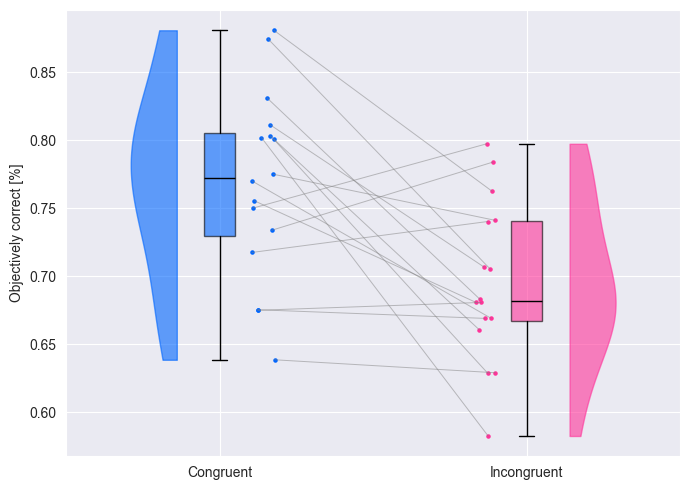

In [18]:
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['time_since_reversal'] != 0]
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)
print(combined_results_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_congruency'
)

In [19]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = [-6, 6]
static_mapping = {
    0: 'subject_id',
    1: 'stimuli_type',
    2: 'congruency',
}

# pick the first and last values you want in the numeric run
start_value = plot_range[0]
end_value   = plot_range[1]

# build the list of values
values = list(range(start_value, end_value + 1))

# compute where the keys should start (one past your highest static key)
start_key = max(static_mapping) + 1

# zip them together into a dict
numeric_mapping = dict(zip(range(start_key, start_key + len(values)), values))

# merge
mapping = {**static_mapping, **numeric_mapping}

print(mapping)

group_name = 'congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_reversals_dataframe)

{0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: -6, 4: -5, 5: -4, 6: -3, 7: -2, 8: -1, 9: 0, 10: 1, 11: 2, 12: 3, 13: 4, 14: 5, 15: 6}
     subject_id  trial  stimuli_type  probability_condition  reversal  \
0       sub-005     11             1                     80     False   
1       sub-005     13             1                     80     False   
2       sub-005     14             1                     80     False   
3       sub-005     16             1                     80     False   
4       sub-005     18             1                     80     False   
...         ...    ...           ...                    ...       ...   
9581    sub-037    656             2                     20      True   
9582    sub-037    660             2                     20     False   
9583    sub-037    661             2                     20     False   
9584    sub-037    663             2                     20     False   
9585    sub-037    667             2                 

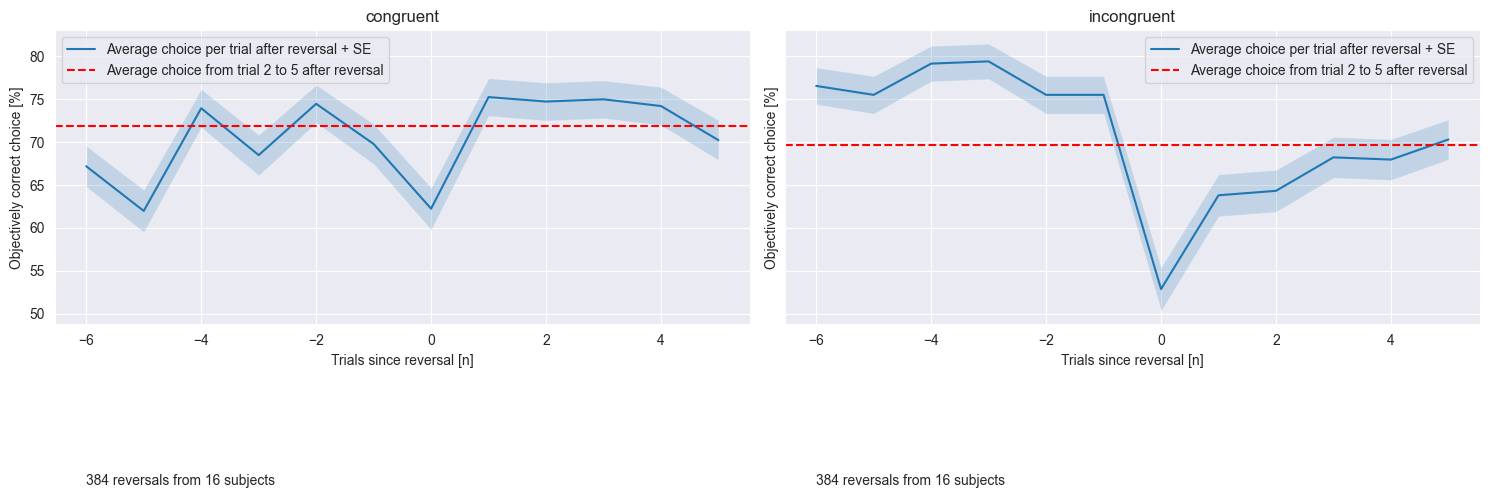

In [20]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_reversals_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 after reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials since reversal [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].text(-6, 30, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

#plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency_before_and_after.pdf'))
plt.show()
plot_range = [0, 6]

# Chance of a forward response around reversal
Here, we plot the chance of a forward response around a reversal, hoping to capture a flip in the reversal for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [21]:
# First create a new dataframe with the 
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1] - 1]
dataframe = utils.analysis_functions.bin_responses_for_congruency(combined_results_dataframe, adjusted_plot_range, 'stimuli_type')

# Map transitions to congruency
to_flip = {
    'happy_congruent_to_incongruent',
    'happy_incongruent_to_congruent'
}

# build a boolean mask for rows to flip
mask = dataframe['emotional_valence_and_transition'].isin(to_flip)

# apply the flip
dataframe.loc[mask, 'response_int'] = 100 - dataframe.loc[mask, 'response_int']

# define your mapping
mapping = {
    'angry_congruent_to_incongruent':    'congruent_to_incongruent',
    'happy_incongruent_to_congruent':    'incongruent_to_congruent',
    'angry_incongruent_to_congruent':    'incongruent_to_congruent',
    'happy_congruent_to_incongruent':    'congruent_to_incongruent',
    'angry_no_transition':               'no_transition',
    'happy_no_transition':               'no_transition',
}

# create new column
dataframe['transitions_combined'] = (
    dataframe['emotional_valence_and_transition']
     .map(mapping)
     .fillna('unknown')   # optional: catch any unexpected values
)

print(dataframe[['trials_around_reversal','stimuli_type','congruency']])

[0, 31, 58, 67, 72, 79, 85, 90, 99, 128, 157, 166, 173, 182, 189, 194, 199, 230, 256, 261, 268, 273, 280, 287, 296, 301, 332, 358, 367, 372, 379, 388, 393, 402, 431, 457, 465, 472, 480, 487, 491, 495, 526, 552, 557, 564, 569, 576, 583, 591, 596, 626, 653, 658, 667, 674, 681, 686, 691, 720, 747, 756, 765, 772, 779, 788, 794, 825, 856, 861, 867, 872, 881, 886, 895, 900, 930, 957, 962, 971, 978, 985, 990, 995, 1024, 1051, 1060, 1069, 1076, 1083, 1092, 1099, 1130, 1161, 1166, 1173, 1178, 1187, 1192, 1201, 1234, 1261, 1267, 1272, 1277, 1283, 1288, 1295, 1321, 1352, 1357, 1365, 1369, 1375, 1384, 1393, 1420, 1446, 1453, 1458, 1464, 1473, 1480, 1488, 1493, 1522, 1548, 1555, 1560, 1565, 1572, 1577, 1584, 1610, 1641, 1646, 1655, 1660, 1667, 1676, 1685, 1713, 1740, 1746, 1750, 1758, 1766, 1772, 1781, 1811, 1839, 1848, 1857, 1864, 1871, 1877, 1882, 1913, 1944, 1953, 1958, 1967, 1972, 1977, 1984, 2011, 2040, 2049, 2056, 2061, 2066, 2073, 2082, 2087, 2112, 2139, 2148, 2155, 2162, 2169, 2176, 2181, 2

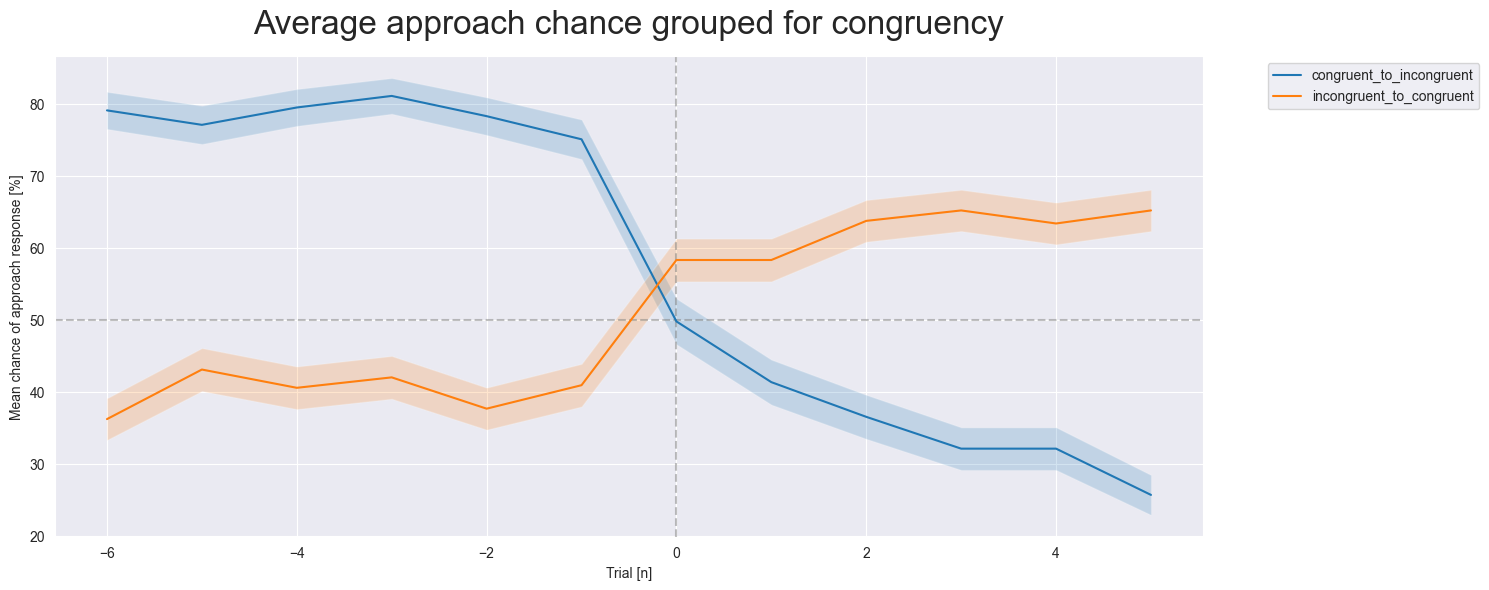

In [22]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_reversal', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for transition in transitions:
    subset = grouped_dataframe[grouped_dataframe['transitions_combined'] == transition]
    current_transition = subset['transitions_combined'].unique()
    if not subset.empty:
        plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{transition}')
        plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for congruency', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_congruency.pdf'))
# Show the plot
plt.show()

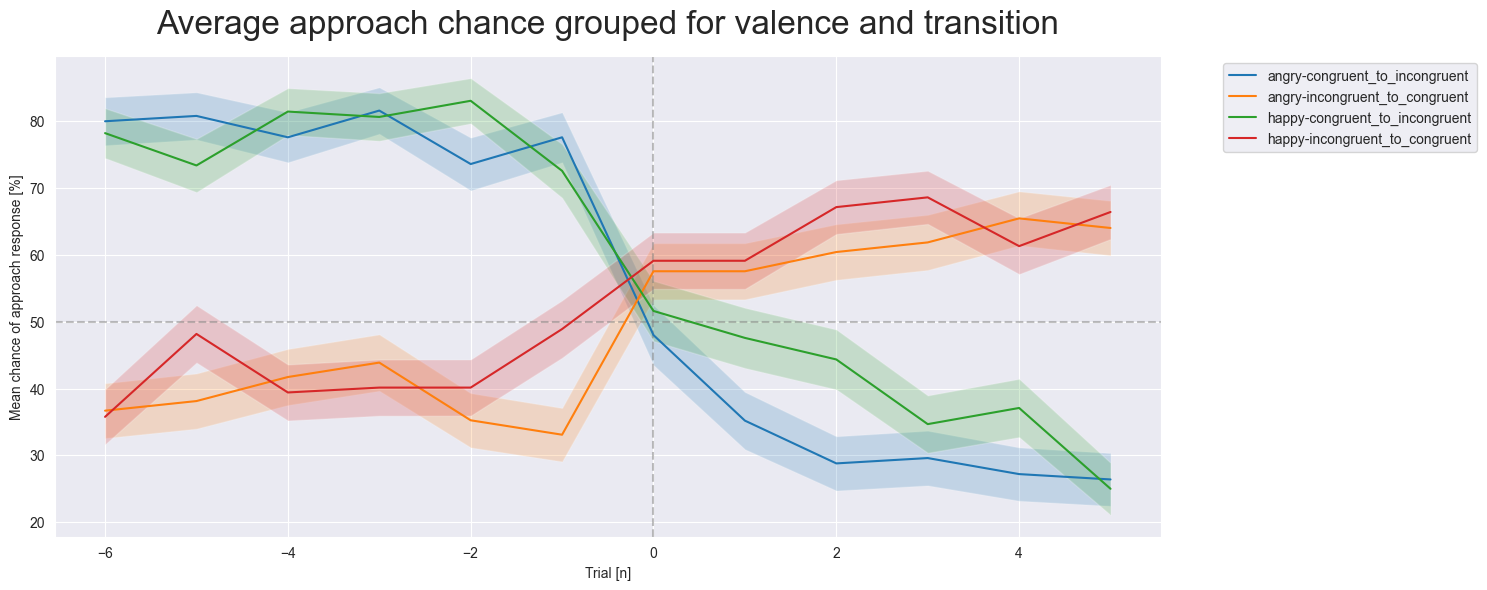

In [23]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_reversal', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_valence_and_transition.pdf'))
# Show the plot
plt.show()

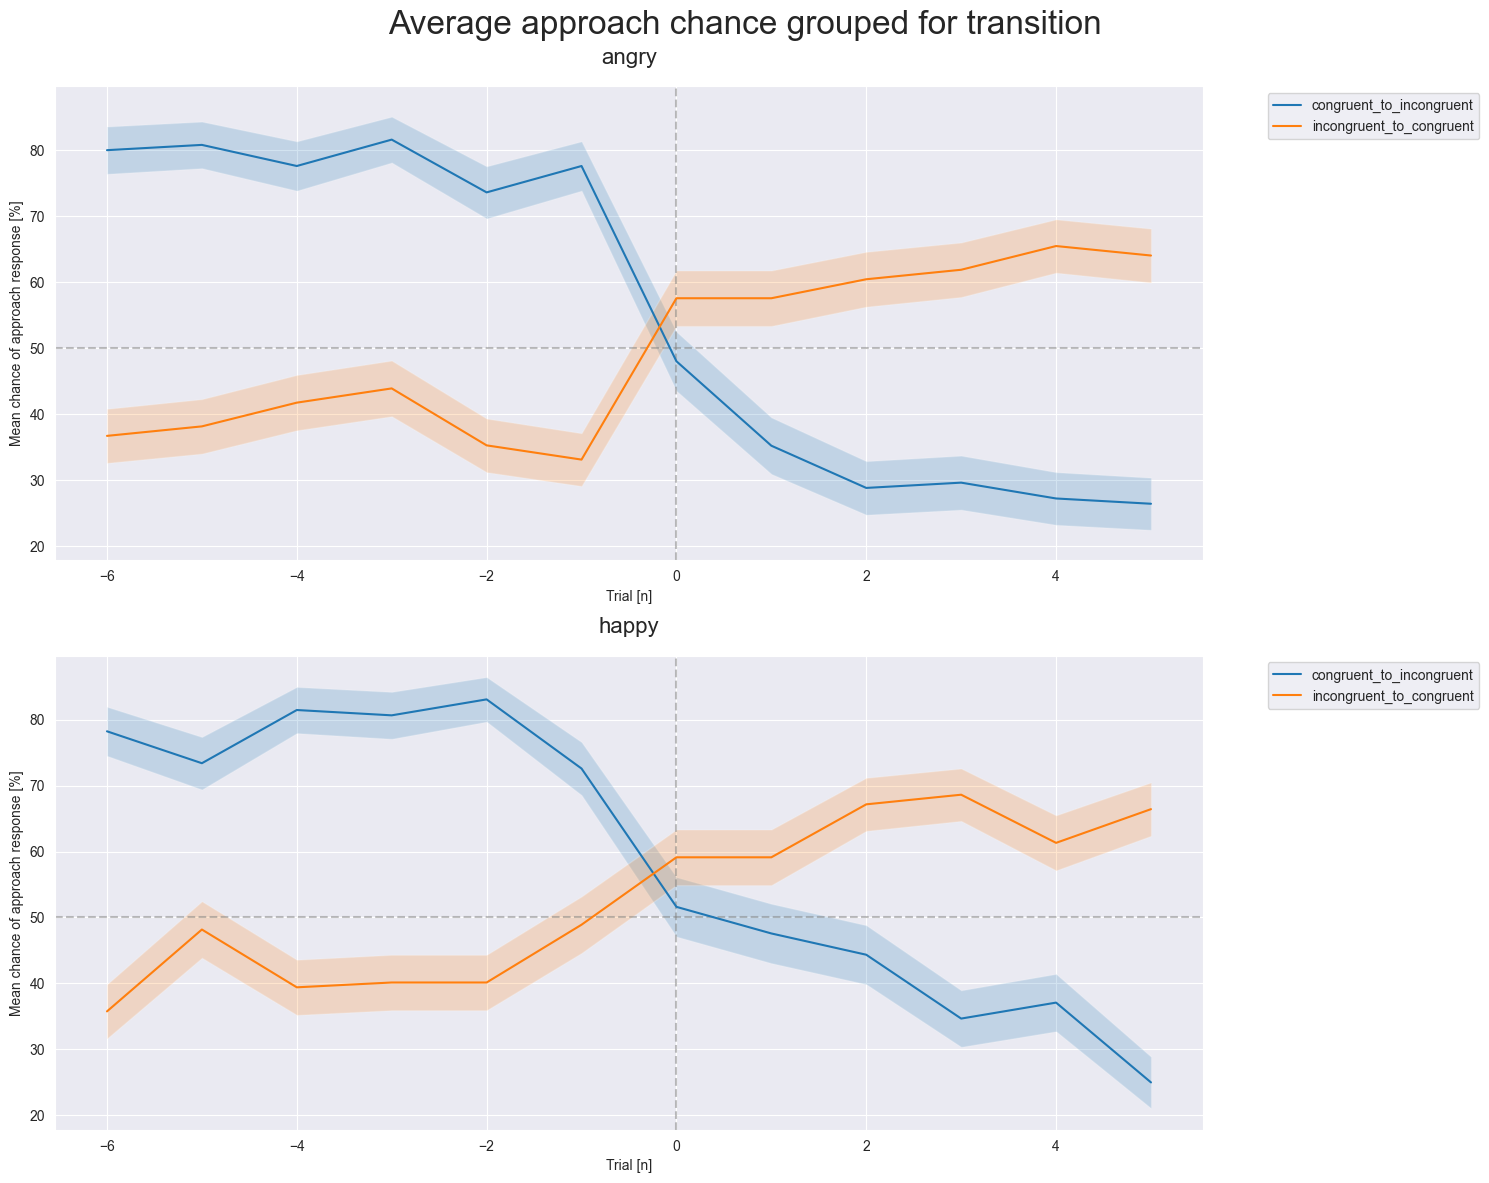

In [24]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_reversal'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_valence_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

In [25]:
# Add a plot where the two emotions are combined and one transition is inverted to compare them bettter

# Plot volatile and stable blocks separately
Fix this, clearly broken

In [26]:
'''pd.set_option('display.max_rows', None)
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe[['subject_id', 'session', 'trial', 'stimuli_type', 'probability_condition', 'volatility']])'''
dataframe = combined_results_dataframe
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
1         9        1.741364e+09     down                True   
1        11        1.741364e+09       up                True   
2        12        1.741364e+09     down                True   
2        13        1.741364e+09       up                True   
3        14        1.741364e+09       up                True   
...     ...                 ...      ...                 ...   
5278    663        1.753192e+09       up               False   
5277    664        1.753192e+09       up                True   
5278    665        1.753192e+09     down               False   
5279    666        1.753192e+09       up                True   
5279    667        1.753192e+09     down                True   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
1                    True   1.741364e+09  0.755   1.741364e+09             2   
1                    True   1.741364e+09  0.735   1.741364e+09         

In [27]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}
group_name = 'volatility'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()
pd.set_option('display.max_rows', 20)
dataframe_with_session = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping, session_name)

print(dataframe_with_session)

dataframe_without_session = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping)

print(dataframe_without_session)

     subject_id  trial  stimuli_type  probability_condition  reversal  \
0       sub-005     11             1                     80     False   
1       sub-005     13             1                     80     False   
2       sub-005     14             1                     80     False   
3       sub-005     16             1                     80     False   
4       sub-005     18             1                     80     False   
...         ...    ...           ...                    ...       ...   
9581    sub-037    656             2                     20      True   
9582    sub-037    660             2                     20     False   
9583    sub-037    661             2                     20     False   
9584    sub-037    663             2                     20     False   
9585    sub-037    667             2                     20     False   

     volatility     session  
0      volatile  session-01  
1      volatile  session-01  
2      volatile  session-01  
3  

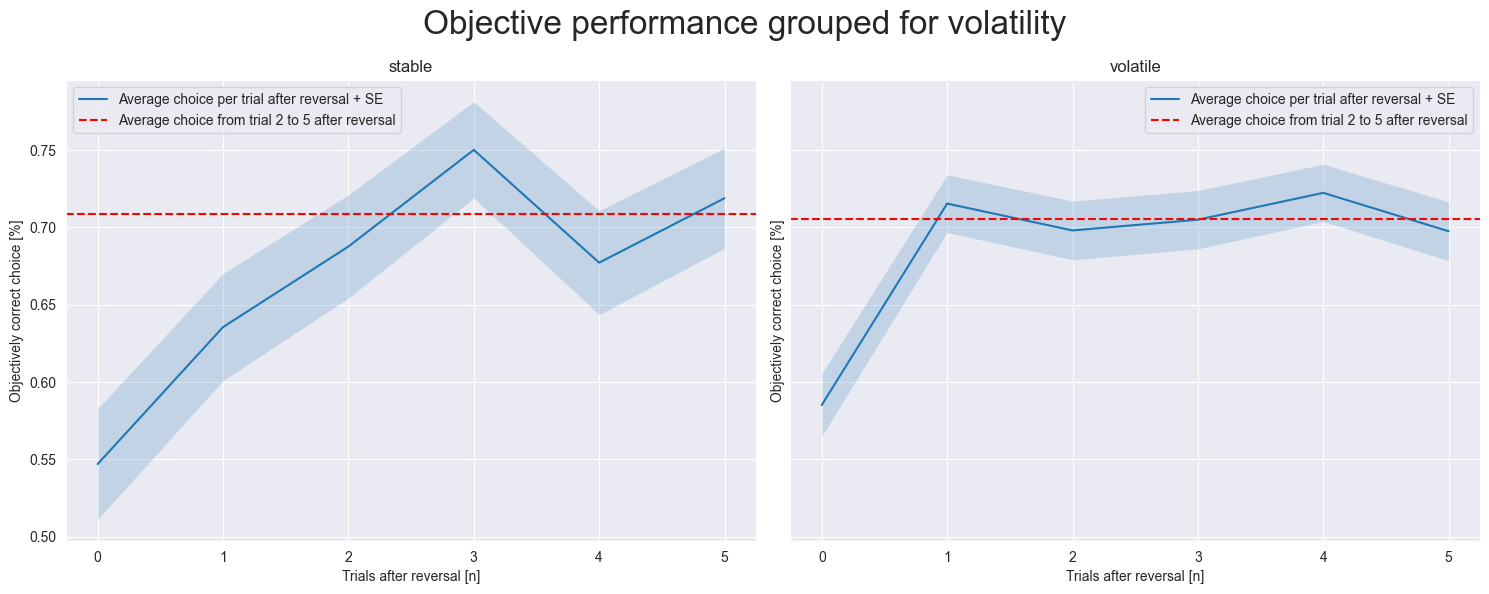

In [28]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe_without_session.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe_without_session['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 after reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_type)
    axs[i].set_xlabel('Trials after reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    #axs[i].text(0, 0.75, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility.pdf'))
plt.show()

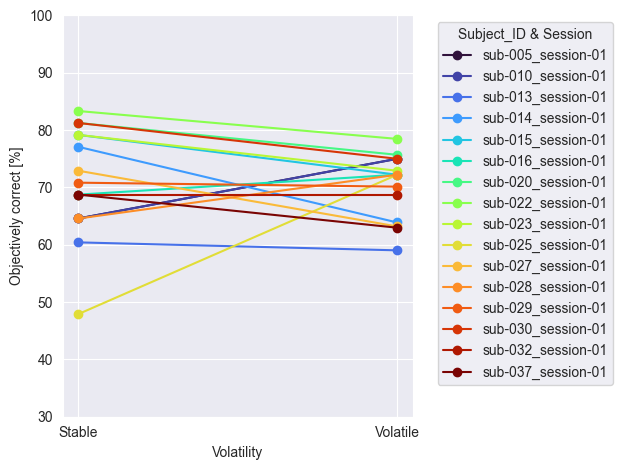

In [29]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe_with_session.set_index('volatility')
df['subject_id_session'] = df['subject_id'] + '_' + df['session']

unique_subjects = df['subject_id_session'].unique()
subject_counts = len(unique_subjects)

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['volatility','subject_id_session']).mean()
means_overall = means*100
means_overall = means_overall.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1)

df = average_choice_after_reversal_total.reset_index()

# Create a mapping for congruency values to x-axis positions:
# 1 for 'congruent' and 2 for 'incongruent'
x_mapping = {'stable': 1, 'volatile': 2}
df['x'] = df['volatility'].map(x_mapping)

colour = iter(cm.turbo(np.linspace(0, 1, len(unique_subject_ids))))
prev_subject = None

# Loop through each subject and plot their corresponding data points
for subject in df['subject_id_session'].unique():
    subject_data = df[df['subject_id_session'] == subject].sort_values(by='x')
    subject_data['value'] = subject_data.iloc[:,2]
    value_congruent = subject_data.loc[subject_data['volatility'] == 'stable', 'value'].iloc[0]
    value_incongruent = subject_data.loc[subject_data['volatility'] == 'volatile', 'value'].iloc[0]

    # If the subject changes, increment the counter
    current_subject = subject.split('_')[0]
    if current_subject != prev_subject:
        line_colour = next(colour)
        prev_subject = current_subject

    # Choose colour based on comparison: green if incongruent is lower, red if higher
    if value_incongruent < value_congruent:
        line_color = 'green'
    elif value_incongruent > value_congruent:
        line_color = 'red'
    else:
        line_color = 'blue'  # Fallback colour if both values are equal

    plt.plot(subject_data['x'], subject_data.iloc[:, 2], marker='o', label=subject, color=line_colour)

# Set x-axis ticks and labels
plt.xticks([1, 2], ['Stable', 'Volatile'])
plt.xlabel('Volatility')
plt.ylabel('Objectively correct [%]')  # Replace 'Value' with your actual y-axis label if needed
#plt.title('Low to high is inverted')
plt.ylim(30, 100)

# Optional: display a legend if the number of subjects is not too high
plt.legend(title='Subject_ID & Session', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_comparing_volatility.pdf'))
plt.show()

   subject_id     session    stable  volatile
0     sub-005  session-01  0.822823  0.756654
1     sub-010  session-01  0.771084  0.776978
2     sub-013  session-01  0.647799  0.616858
3     sub-014  session-01  0.701754  0.632812
4     sub-015  session-01  0.787611  0.719557
5     sub-016  session-01  0.770149  0.692015
6     sub-020  session-01  0.860119  0.781132
7     sub-022  session-01  0.746269  0.775281
8     sub-023  session-01  0.785498  0.733333
9     sub-025  session-01  0.716814  0.722222
10    sub-027  session-01  0.755952  0.675373
11    sub-028  session-01  0.723724  0.733840
12    sub-029  session-01  0.712991  0.677903
13    sub-030  session-01  0.792285  0.722846
14    sub-032  session-01  0.737342  0.703125
15    sub-037  session-01  0.718101  0.627306


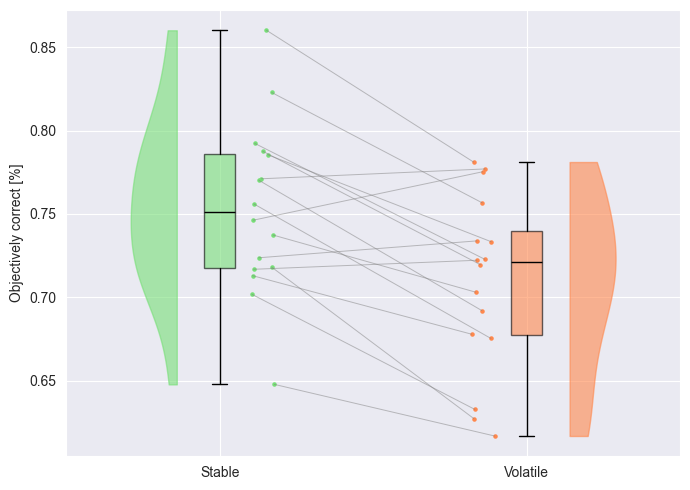

In [30]:
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)
print(combined_results_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_volatility',
    colours=['#77DF77', '#FF884D']
)

   subject_id     session  congruent_stable  congruent_volatile  \
0     sub-005  session-01          0.884393            0.862319   
1     sub-010  session-01          0.771605            0.725352   
2     sub-013  session-01          0.648810            0.625000   
3     sub-014  session-01          0.708333            0.635714   
4     sub-015  session-01          0.751479            0.714286   
5     sub-016  session-01          0.822485            0.780822   
6     sub-020  session-01          0.898810            0.860927   
7     sub-022  session-01          0.776471            0.773333   
8     sub-023  session-01          0.860606            0.758170   
9     sub-025  session-01          0.857988            0.736842   
10    sub-027  session-01          0.809524            0.695364   
11    sub-028  session-01          0.704819            0.731544   
12    sub-029  session-01          0.834356            0.766667   
13    sub-030  session-01          0.869822            0.78807

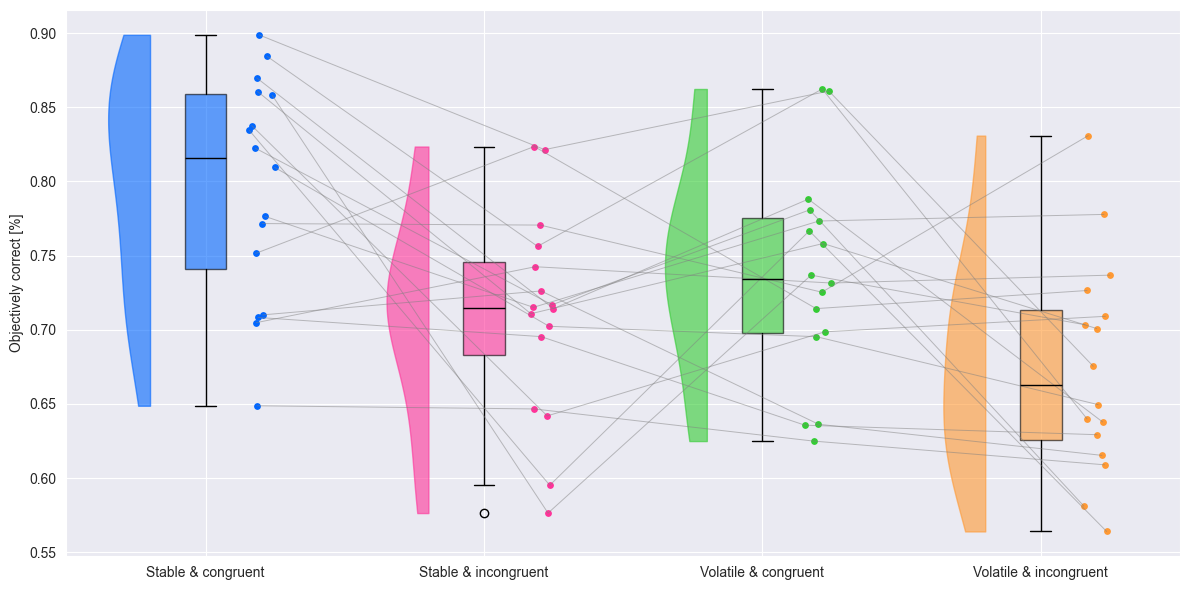

In [31]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['congruency','volatility'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_congruency_volatility'
)

# Now do the same thing but split them for congruency & volatility

In [32]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 'volatility', 4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_reversals_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', plot_range, mapping, 'congruency')

#print(dataframe)

     subject_id  trial  stimuli_type  probability_condition  reversal  \
0       sub-005     11             1                     80     False   
1       sub-005     13             1                     80     False   
2       sub-005     14             1                     80     False   
3       sub-005     16             1                     80     False   
4       sub-005     18             1                     80     False   
...         ...    ...           ...                    ...       ...   
9581    sub-037    656             2                     20      True   
9582    sub-037    660             2                     20     False   
9583    sub-037    661             2                     20     False   
9584    sub-037    663             2                     20     False   
9585    sub-037    667             2                     20     False   

     volatility congruency  
0      volatile  congruent  
1      volatile  congruent  
2      volatile  congruent  
3      

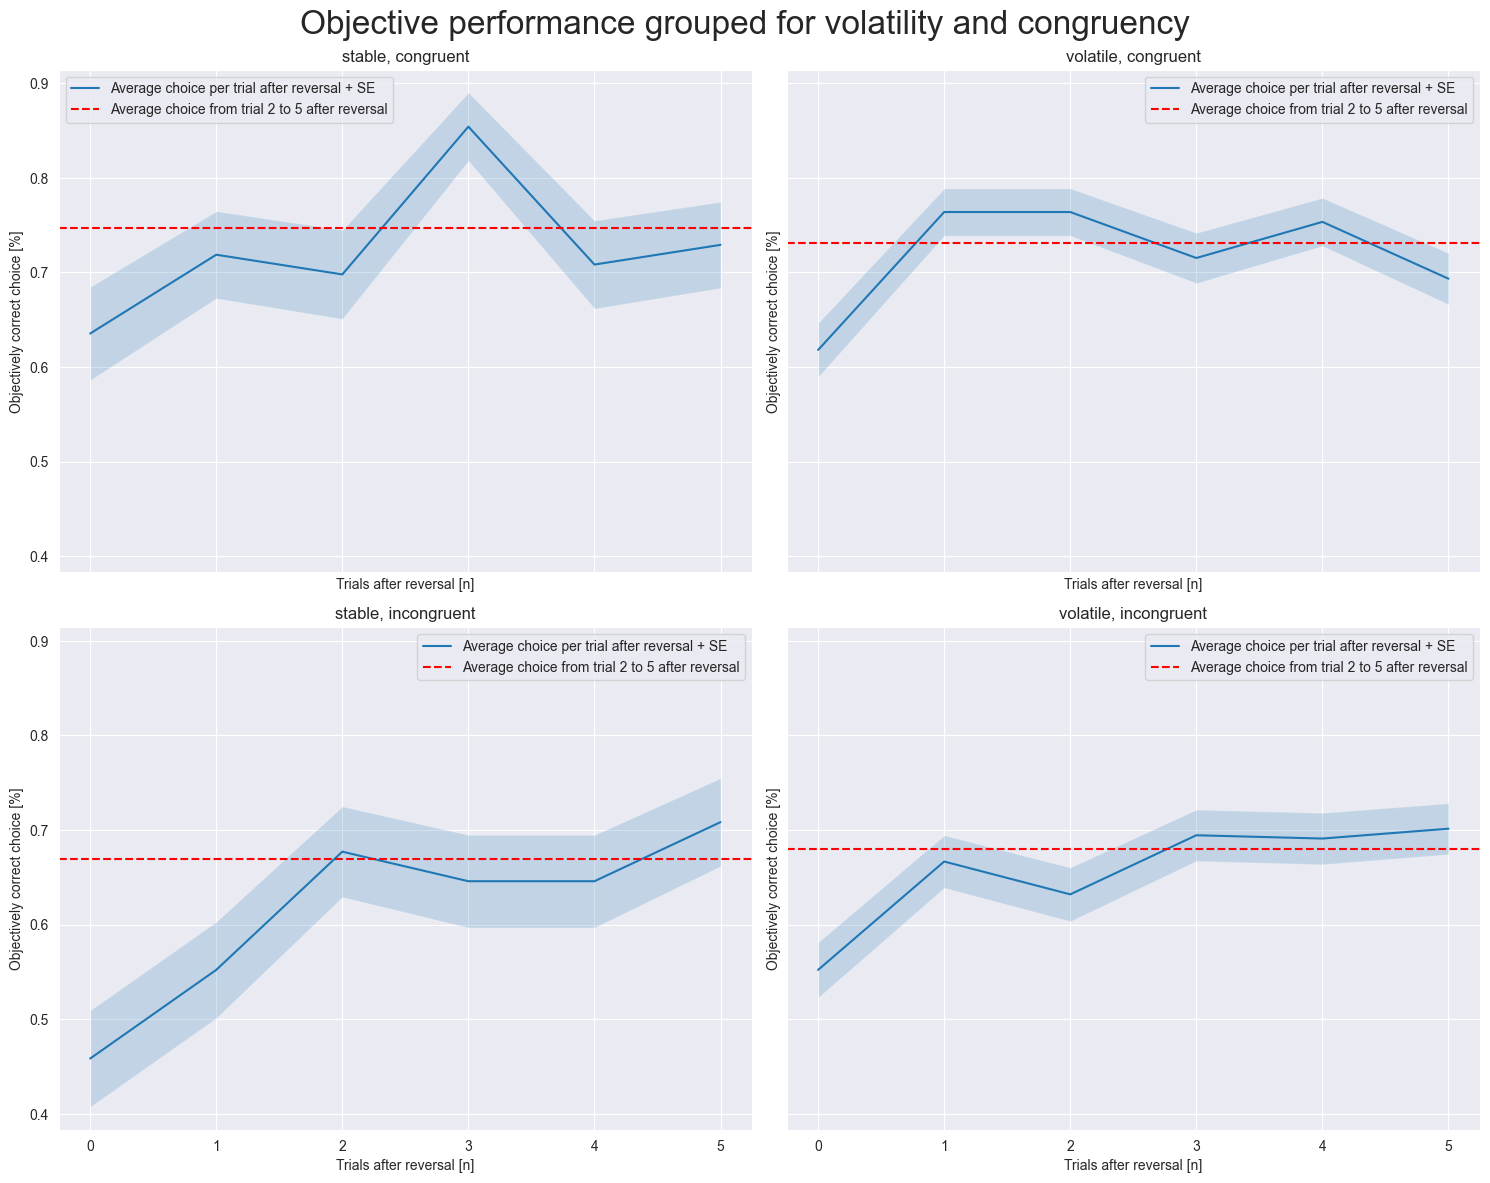

In [33]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'volatility']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'volatility']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 after reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility_and_congruency.pdf'))
plt.show()

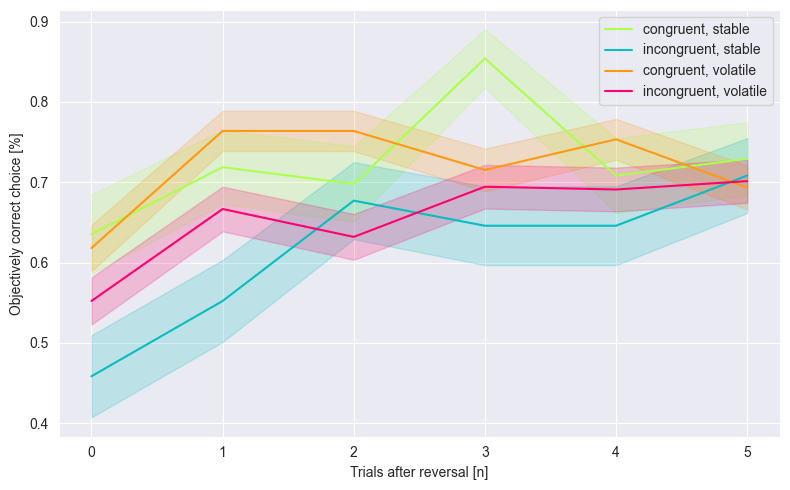

In [34]:
df_long = dataframe.melt(
    id_vars=['subject_id', 'stimuli_type', 'volatility', 'congruency'],
    value_vars=[0, 1, 2, 3, 4, 5],
    var_name='time',
    value_name='value'
)
# Convert the time column to integers
df_long['time'] = df_long['time'].astype(int)

# Compute mean and standard error of the mean (SEM)
summary = (
    df_long
    .groupby(['volatility', 'congruency', 'time'])['value']
    .agg(['mean', 'sem'])
    .reset_index()
)

colour = ['#ABFF4F','#08BDBD','#FF9914','#FF006E']

# 3) Plot with shaded error bands
fig, ax = plt.subplots(figsize=(8, 5))
for idx, ((vol, cong), grp) in enumerate(summary.groupby(['volatility', 'congruency'])):
    x = grp['time']
    y = grp['mean']
    yerr = grp['sem']
    # draw the line
    line, = ax.plot(
        x, y,
        label=f'{cong}, {vol}',
        color=colour[idx],
    )
    # use same colour for the fill, with transparency
    #colour = line.get_color()
    ax.fill_between(
        x,
        y - yerr,
        y + yerr,
        color=colour[idx],
        alpha=0.2
    )

ax.set_xlabel('Trials after reversal [n]')
ax.set_ylabel('Objectively correct choice [%]')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_combined_for_volatility_and_congruency.pdf'))
plt.show()

# Plot the full stable block

In [35]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create a dictionary based on the plot range
initial_columns = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility'}
adjusted_plot_range = [0, 28]
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+3: v for k, v in enumerate(plot_range)})

# Define the to be plotted factor
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = utils.analysis_functions.find_reversals_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', adjusted_plot_range, mapping)

print(dataframe)

     subject_id  trial  stimuli_type  probability_condition  reversal  \
0       sub-005     11             1                     80     False   
1       sub-005     13             1                     80     False   
2       sub-005     14             1                     80     False   
3       sub-005     16             1                     80     False   
4       sub-005     18             1                     80     False   
...         ...    ...           ...                    ...       ...   
9581    sub-037    656             2                     20      True   
9582    sub-037    660             2                     20     False   
9583    sub-037    661             2                     20     False   
9584    sub-037    663             2                     20     False   
9585    sub-037    667             2                     20     False   

     volatility  
0      volatile  
1      volatile  
2      volatile  
3      volatile  
4      volatile  
...         ...

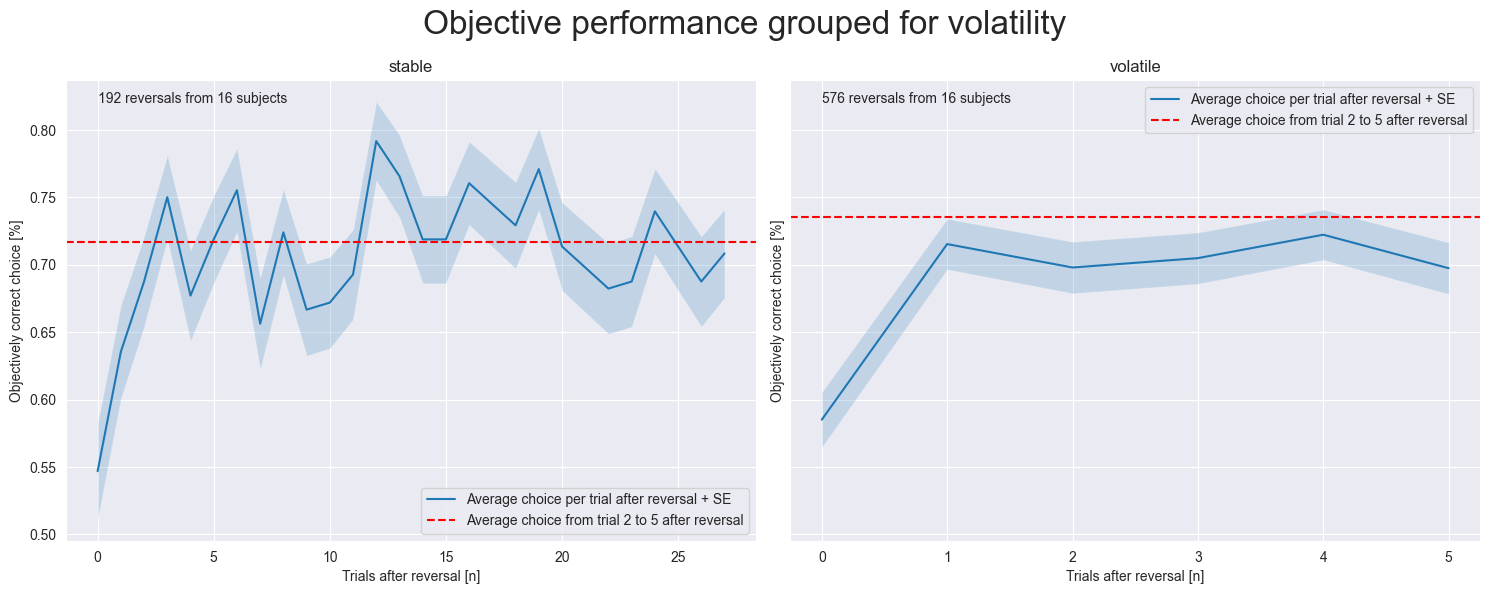

In [36]:
# Remove volatile rows
df = dataframe.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = (means_overall.mean(axis=1).tolist())
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values

    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]
    
    if congruency_type == 'stable':
        timepoints = list(range(adjusted_plot_range[0], adjusted_plot_range[1]))
    else:
        volatile_duration = 6
        timepoints = list(range(0, volatile_duration))
        mean_values = mean_values.iloc[:volatile_duration]
        std_values = std_values.iloc[:volatile_duration]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline(average_choice_after_reversal_total[i], color='r', linestyle='--', label='Average choice from trial 2 to 5 after reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after reversal [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.82, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_for_full_stable_block.pdf'))
plt.show()

In [37]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Then bin the area around a reversal
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1] - 1]
dataframe = utils.analysis_functions.bin_responses_for_congruency(dataframe, adjusted_plot_range, 'volatility')

# Map transitions to congruency
to_flip = {
    'happy_congruent_to_incongruent',
    'happy_incongruent_to_congruent'
}

# build a boolean mask for rows to flip
mask = dataframe['emotional_valence_and_transition'].isin(to_flip)

# apply the flip
dataframe.loc[mask, 'response_int'] = 100 - dataframe.loc[mask, 'response_int']

# define your mapping
mapping = {
    'angry_congruent_to_incongruent':    'congruent_to_incongruent',
    'happy_incongruent_to_congruent':    'incongruent_to_congruent',
    'angry_incongruent_to_congruent':    'incongruent_to_congruent',
    'happy_congruent_to_incongruent':    'congruent_to_incongruent',
    'angry_no_transition':               'no_transition',
    'happy_no_transition':               'no_transition',
}

# create new column
dataframe['transitions_combined'] = (
    dataframe['emotional_valence_and_transition']
     .map(mapping)
     .fillna('unknown')   # optional: catch any unexpected values
)

print(dataframe)

[0, 31, 58, 67, 72, 79, 85, 90, 99, 128, 157, 166, 173, 182, 189, 194, 199, 230, 256, 261, 268, 273, 280, 287, 296, 301, 332, 358, 367, 372, 379, 388, 393, 402, 431, 457, 465, 472, 480, 487, 491, 495, 526, 552, 557, 564, 569, 576, 583, 591, 596, 626, 653, 658, 667, 674, 681, 686, 691, 720, 747, 756, 765, 772, 779, 788, 794, 825, 856, 861, 867, 872, 881, 886, 895, 900, 930, 957, 962, 971, 978, 985, 990, 995, 1024, 1051, 1060, 1069, 1076, 1083, 1092, 1099, 1130, 1161, 1166, 1173, 1178, 1187, 1192, 1201, 1234, 1261, 1267, 1272, 1277, 1283, 1288, 1295, 1321, 1352, 1357, 1365, 1369, 1375, 1384, 1393, 1420, 1446, 1453, 1458, 1464, 1473, 1480, 1488, 1493, 1522, 1548, 1555, 1560, 1565, 1572, 1577, 1584, 1610, 1641, 1646, 1655, 1660, 1667, 1676, 1685, 1713, 1740, 1746, 1750, 1758, 1766, 1772, 1781, 1811, 1839, 1848, 1857, 1864, 1871, 1877, 1882, 1913, 1944, 1953, 1958, 1967, 1972, 1977, 1984, 2011, 2040, 2049, 2056, 2061, 2066, 2073, 2082, 2087, 2112, 2139, 2148, 2155, 2162, 2169, 2176, 2181, 2

# Still needs fix where only transitions of volatile to volatile and stable to stable are used

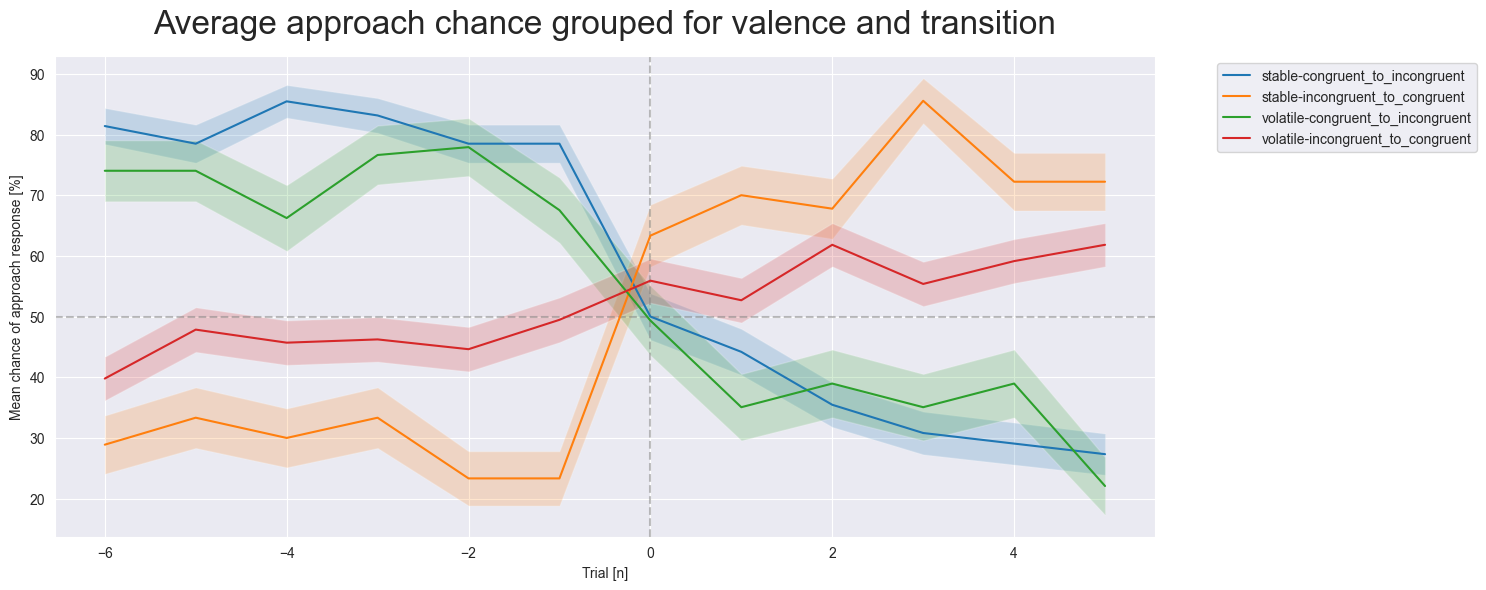

In [38]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_reversal', 'volatility', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition.pdf'))
# Show the plot
plt.show()

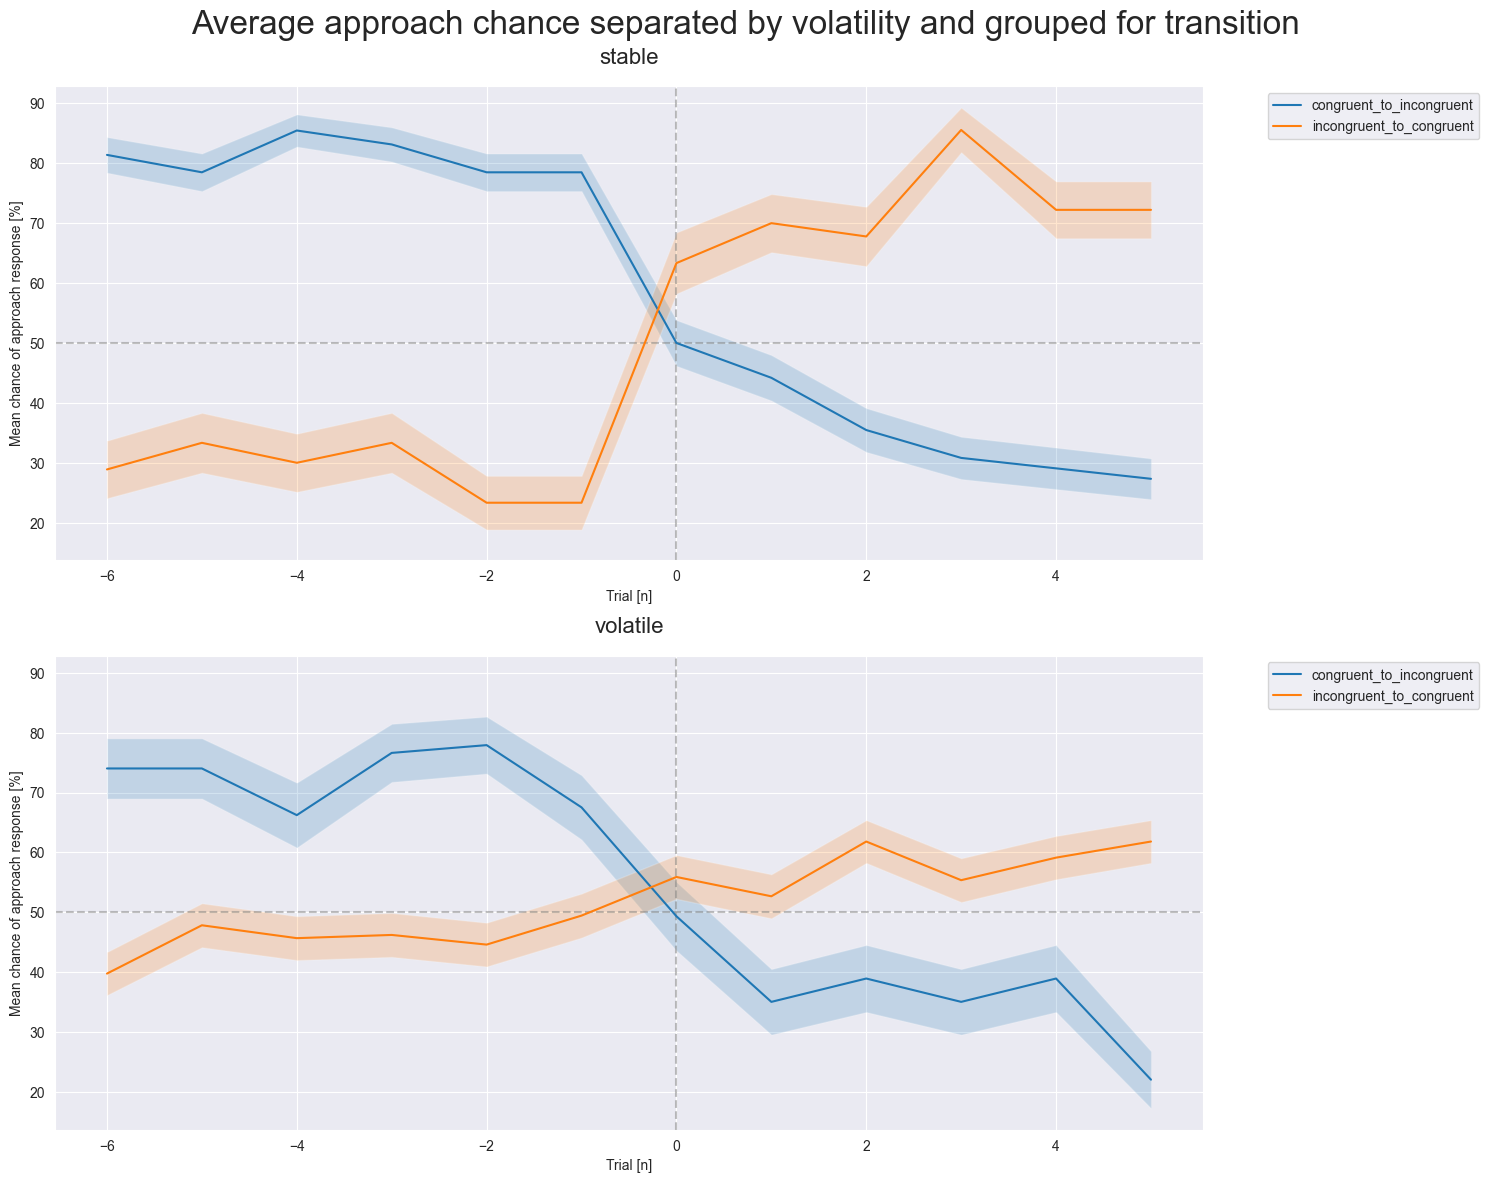

In [39]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance separated by volatility and grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence_value) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_reversal'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_volatility_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

# Overall objective performance over time
This will be used to check whether their performance stabilises after the 1st session

In [40]:
all_session_labels = ['session-01', 'session-02', 'session-03', 'session-04']
if all(s in unique_sessions for s in all_session_labels):
    # Check if a block is volatile or stable
    dataframe = combined_results_dataframe_all_sessions[combined_results_dataframe_all_sessions['probability_condition'] != 50]
    dataframe = utils.analysis_functions.check_volatility(dataframe)
    dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

    # Single-pass aggregation & reshape
    combined_results_pivoted = dataframe[dataframe['time_since_reversal'] != 0]
    combined_results_pivoted = (
        combined_results_pivoted
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['congruency', 'volatility'],
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        f"{a}_{b}" if b else a
        for a, b in combined_results_pivoted.columns
    ]
    print(combined_results_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_scatter_violin_box_2x2(
        combined_results_pivoted,
        columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
        subject_col='subject_id',
        session_col='session',
        labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
        output_dir=output_dir,
        ylabel_name='Objectively correct choice [%]',
        plot_name='all_trials_objective_performance_comparing_congruency_and_volatility'
    )